# Data Prep

In [1]:
import os

csv_files = [f for f in os.listdir('data') if f.endswith('.csv')]


In [2]:
csv_files 

['CBBCHUSD.csv',
 'CBBTCUSD.csv',
 'CBETHUSD.csv',
 'CBLTCUSD.csv',
 'DTWEXBGS.csv',
 'FAMA.csv',
 'MSF_1996_2023.csv',
 'NASDAQQGLDI.csv',
 'VDE.csv']

In [3]:
import pandas as pd

CBBCHUSD = pd.read_csv(os.path.join('data', 'CBBCHUSD.csv'))
CBBTCUSD = pd.read_csv(os.path.join('data', 'CBBTCUSD.csv'))
CBETHUSD = pd.read_csv(os.path.join('data', 'CBETHUSD.csv'))
CBLTCUSD = pd.read_csv(os.path.join('data', 'CBLTCUSD.csv'))
DTWEXBGS = pd.read_csv(os.path.join('data', 'DTWEXBGS.csv'))
MSF_1996_2023 = pd.read_csv(os.path.join('data', 'MSF_1996_2023.csv'))
NASDAQQGLDI = pd.read_csv(os.path.join('data', 'NASDAQQGLDI.csv'))
VDE = pd.read_csv(os.path.join('data', 'VDE.csv'))
FAMA = pd.read_csv(os.path.join('data', 'FAMA.csv'))


C:\Users\jmani\AppData\Local\Temp\ipykernel_42544\2157190922.py:8: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  MSF_1996_2023 = pd.read_csv(os.path.join('data', 'MSF_1996_2023.csv'))


In [4]:
# The first column is the date column in each dataframe.
daily_dfs = [
    ('CBBCHUSD', CBBCHUSD),
    ('CBBTCUSD', CBBTCUSD),
    ('CBETHUSD', CBETHUSD),
    ('CBLTCUSD', CBLTCUSD),
    ('DTWEXBGS', DTWEXBGS),
    ('NASDAQQGLDI', NASDAQQGLDI),
    ('VDE', VDE),
]

monthly_dfs = {}

for name, df in daily_dfs:
    # Assume the first column is always the date column
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(by=date_col)
    # Resample to month end, taking the last available value each month
    df_monthly = df.set_index(date_col).resample('M').last().reset_index()
    monthly_dfs[name + '_monthly'] = df_monthly

# Assign to variables in the notebook's namespace:
CBBCHUSD_monthly = monthly_dfs['CBBCHUSD_monthly']
CBBTCUSD_monthly = monthly_dfs['CBBTCUSD_monthly']
CBETHUSD_monthly = monthly_dfs['CBETHUSD_monthly']
CBLTCUSD_monthly = monthly_dfs['CBLTCUSD_monthly']
DTWEXBGS_monthly = monthly_dfs['DTWEXBGS_monthly']
NASDAQQGLDI_monthly = monthly_dfs['NASDAQQGLDI_monthly']
VDE_monthly = monthly_dfs['VDE_monthly']


C:\Users\jmani\AppData\Local\Temp\ipykernel_42544\2016690768.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index(date_col).resample('M').last().reset_index()
C:\Users\jmani\AppData\Local\Temp\ipykernel_42544\2016690768.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index(date_col).resample('M').last().reset_index()
C:\Users\jmani\AppData\Local\Temp\ipykernel_42544\2016690768.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index(date_col).resample('M').last().reset_index()
C:\Users\jmani\AppData\Local\Temp\ipykernel_42544\2016690768.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index(date_col).resample('M').last().reset_index()
C:\Users\jmani\AppData\Local\Temp\ipyker

In [5]:
FAMA

,date,Mkt-RF,SMB,HML,RF
0,192607,2.89,-2.55,-2.39,0.22
1,192608,2.64,-1.14,3.81,0.25
2,192609,0.38,-1.36,0.05,0.23
3,192610,-3.27,-0.14,0.82,0.32
4,192611,2.54,-0.11,-0.61,0.31
...,...,...,...,...,...
1185,202504,-0.84,-0.59,-3.40,0.35
1186,202505,6.06,0.70,-2.88,0.38
1187,202506,4.86,0.83,-1.60,0.34
1188,202507,1.98,0.27,-1.27,0.34


In [6]:
for df_name in [
    'CBBCHUSD_monthly',
    'CBBTCUSD_monthly',
    'CBETHUSD_monthly',
    'CBLTCUSD_monthly',
    'DTWEXBGS_monthly',
    'NASDAQQGLDI_monthly',
    'VDE_monthly',
    'MSF_1996_2023',
]:
    df = globals()[df_name]
    # The first column is always the date
    date_col = df.columns[0]
    df['year'] = pd.to_datetime(df[date_col]).dt.year
    df['month'] = pd.to_datetime(df[date_col]).dt.month
    # Reorder columns: year, month, rest
    cols = ['year', 'month'] + [c for c in df.columns if c not in ['year', 'month', date_col]]
    df = df[cols]
    globals()[df_name] = df



In [7]:
FAMA = FAMA.copy()
FAMA['year'] = FAMA['date'].astype(str).str[:4].astype(int)
FAMA['month'] = FAMA['date'].astype(str).str[4:6].astype(int)
cols = ['year', 'month'] + [col for col in FAMA.columns if col not in ['year', 'month', 'date']]
FAMA = FAMA[cols]
FAMA

,year,month,Mkt-RF,SMB,HML,RF
0,1926,7,2.89,-2.55,-2.39,0.22
1,1926,8,2.64,-1.14,3.81,0.25
2,1926,9,0.38,-1.36,0.05,0.23
3,1926,10,-3.27,-0.14,0.82,0.32
4,1926,11,2.54,-0.11,-0.61,0.31
...,...,...,...,...,...,...
1185,2025,4,-0.84,-0.59,-3.40,0.35
1186,2025,5,6.06,0.70,-2.88,0.38
1187,2025,6,4.86,0.83,-1.60,0.34
1188,2025,7,1.98,0.27,-1.27,0.34


In [8]:
CBBCHUSD_monthly

,year,month,CBBCHUSD
0,2017,12,2366.90
1,2018,1,1472.74
2,2018,2,1195.94
3,2018,3,683.01
4,2018,4,1350.49
...,...,...,...
90,2025,6,500.49
91,2025,7,535.65
92,2025,8,545.63
93,2025,9,593.04


In [9]:
MSF_1996_2023 = MSF_1996_2023.copy()
MSF_1996_2023['date'] = pd.to_datetime(MSF_1996_2023['date'])
MSF_1996_2023['year'] = MSF_1996_2023['date'].dt.year
MSF_1996_2023['month'] = MSF_1996_2023['date'].dt.month
cols = ['year', 'month'] + [col for col in MSF_1996_2023.columns if col not in ['year', 'month']]
MSF_1996_2023 = MSF_1996_2023[cols]
MSF_1996_2023

,year,month,date,SICCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd
0,1996,1,1996-01-31,4920,EWST,ENERGY WEST INC,7953,-9.12500,168.0,-0.026667,2281.0,-0.026667,0.028121
1,1996,2,1996-02-29,4920,EWST,ENERGY WEST INC,7953,9.25000,524.0,0.013699,2281.0,0.013699,0.016353
2,1996,3,1996-03-29,4920,EWST,ENERGY WEST INC,7953,9.48438,283.0,0.036149,2309.0,0.025338,0.010914
3,1996,4,1996-04-30,4920,EWST,ENERGY WEST INC,7953,-8.81250,327.0,-0.07084,2309.0,-0.07084,0.025560
4,1996,5,1996-05-31,4920,EWST,ENERGY WEST INC,7953,8.62500,103.0,-0.021277,2309.0,-0.021277,0.026810
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2016,10,2016-10-31,2731,JW,WILEY JOHN & SONS INC,4922,52.60000,49.0,-0.023031,9475.0,-0.023031,-0.021544
1048571,2016,11,2016-11-30,2731,JW,WILEY JOHN & SONS INC,4922,54.81000,149.0,0.042015,9475.0,0.042015,0.040488
1048572,2016,12,2016-12-30,2731,JW,WILEY JOHN & SONS INC,4922,54.67000,168.0,0.003102,9197.0,-0.002554,0.018763
1048573,2017,1,2017-01-31,2731,JW,WILEY JOHN & SONS INC,4922,54.64000,150.0,-0.000549,9197.0,-0.000549,0.022153


In [10]:
MSF_1996_2023_unique = MSF_1996_2023[['year', 'month', 'vwretd']].drop_duplicates()
MSF_1996_2023_unique


,year,month,vwretd
0,1996,1,0.028121
1,1996,2,0.016353
2,1996,3,0.010914
3,1996,4,0.025560
4,1996,5,0.026810
...,...,...,...
1395,2023,8,-0.020605
1396,2023,9,-0.047390
1397,2023,10,-0.028867
1398,2023,11,0.092057


In [11]:
MSF_1996_2023 = MSF_1996_2023_unique

In [12]:
# Merge all provided DataFrames on 'year' and 'month' into a single DataFrame called 'merged'
# Also add FAMA_monthly to the merge

# List all DataFrames to be merged, including FAMA_monthly
dfs_to_merge = [
    CBBCHUSD_monthly,
    CBBTCUSD_monthly,
    CBETHUSD_monthly,
    CBLTCUSD_monthly,
    DTWEXBGS_monthly,
    NASDAQQGLDI_monthly,
    VDE_monthly,
    MSF_1996_2023,
    FAMA  # add fama
]

# Start with the first DataFrame
merged = dfs_to_merge[0]
for df in dfs_to_merge[1:]:
    merged = pd.merge(
        merged,
        df,
        on=['year', 'month'],
        how='outer',
        suffixes=(None, '_dup')
    )

# Optionally, remove duplicate columns from merge if any (e.g. duplicate 'year'/'month')
duplicate_cols = [col for col in merged.columns if col.endswith('_dup')]
merged = merged.drop(columns=duplicate_cols)

# Sort by year and month for neatness
merged = merged.sort_values(['year', 'month']).reset_index(drop=True)


In [13]:
merged

,year,month,CBBCHUSD,CBBTCUSD,CBETHUSD,CBLTCUSD,DTWEXBGS,NASDAQQGLDI,Open,High,Low,Close,Volume,vwretd,Mkt-RF,SMB,HML,RF
0,1926,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.89,-2.55,-2.39,0.22
1,1926,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.64,-1.14,3.81,0.25
2,1926,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.38,-1.36,0.05,0.23
3,1926,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.27,-0.14,0.82,0.32
4,1926,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.54,-0.11,-0.61,0.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1187,2025,6,500.49,105711.78,2405.32,83.26,119.8269,2854.36,119.660,119.89,118.8000,119.12,1649008.0,NaN,4.86,0.83,-1.60,0.34
1188,2025,7,535.65,113248.73,3486.39,106.57,122.1088,2811.67,122.095,123.79,121.9800,122.45,277566.0,NaN,1.98,0.27,-1.27,0.34
1189,2025,8,545.63,109240.55,4314.76,108.73,120.6028,2915.23,126.500,127.27,126.2501,126.89,337582.0,NaN,1.85,3.87,4.41,0.38
1190,2025,9,593.04,118659.97,4350.52,115.16,120.5624,3033.22,126.180,126.38,124.9100,125.86,670411.0,NaN,NaN,NaN,NaN,NaN


In [14]:
# Filter for data between 2015-01 and 2023-12
merged = merged[
    (merged['year'] >= 2015) & 
    (merged['year'] <= 2023) & 
    (merged['month'] >= 1) & 
    (merged['month'] <= 12)
]
merged

,year,month,CBBCHUSD,CBBTCUSD,CBETHUSD,CBLTCUSD,DTWEXBGS,NASDAQQGLDI,Open,High,Low,Close,Volume,vwretd,Mkt-RF,SMB,HML,RF
1062,2015,1,NaN,218.45,NaN,NaN,105.5884,4197.00,78.8529,80.9797,78.2410,79.9888,1.238485e+06,-0.027163,-3.10,-0.59,-3.45,0.00
1063,2015,2,NaN,255.59,NaN,NaN,105.5981,4048.66,84.4782,84.5555,83.8276,83.9020,1.022037e+06,0.055915,6.13,0.61,-1.79,0.00
1064,2015,3,NaN,245.50,NaN,NaN,107.4396,3941.79,82.2886,82.9005,81.8168,82.3051,5.889364e+05,-0.010397,-1.11,3.05,-0.38,0.00
1065,2015,4,NaN,236.81,NaN,NaN,105.3120,3917.44,88.6998,88.7878,87.5765,88.1082,4.038990e+05,0.008766,0.59,-2.99,1.80,0.00
1066,2015,5,NaN,230.21,NaN,NaN,106.7388,3947.20,83.6826,84.0557,83.3916,83.6430,3.756173e+05,0.010277,1.37,0.95,-1.11,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1165,2023,8,207.43,25922.51,1645.28,63.84,120.5882,2485.56,125.0300,125.0300,123.8400,124.6300,3.130000e+05,-0.020605,-2.36,-3.14,-1.15,0.45
1166,2023,9,233.74,26959.40,1670.66,65.95,122.6332,2369.65,129.2900,129.2900,126.3300,126.7400,5.225360e+05,-0.047390,-5.23,-2.51,1.49,0.43
1167,2023,10,245.22,34667.88,1815.73,68.90,124.1229,2478.70,119.6500,120.1600,118.4100,119.9400,5.837610e+05,-0.028867,-3.15,-3.86,0.20,0.47
1168,2023,11,221.59,37743.00,2054.06,69.46,120.5421,2540.61,118.7600,120.3200,117.1500,118.5200,5.395320e+05,0.092057,8.88,-0.10,1.67,0.44


In [15]:
cols_to_drop = [col for col in merged.columns if any(x in col.lower() for x in ['open', 'high', 'low', 'vol'])]
merged = merged.drop(columns=cols_to_drop, errors='ignore')


In [16]:
merged.head()

,year,month,CBBCHUSD,CBBTCUSD,CBETHUSD,CBLTCUSD,DTWEXBGS,NASDAQQGLDI,Close,vwretd,Mkt-RF,SMB,HML,RF
1062,2015,1,NaN,218.45,NaN,NaN,105.5884,4197.00,79.9888,-0.027163,-3.10,-0.59,-3.45,0.0
1063,2015,2,NaN,255.59,NaN,NaN,105.5981,4048.66,83.9020,0.055915,6.13,0.61,-1.79,0.0
1064,2015,3,NaN,245.50,NaN,NaN,107.4396,3941.79,82.3051,-0.010397,-1.11,3.05,-0.38,0.0
1065,2015,4,NaN,236.81,NaN,NaN,105.3120,3917.44,88.1082,0.008766,0.59,-2.99,1.80,0.0
1066,2015,5,NaN,230.21,NaN,NaN,106.7388,3947.20,83.6430,0.010277,1.37,0.95,-1.11,0.0


In [17]:
merged

,year,month,CBBCHUSD,CBBTCUSD,CBETHUSD,CBLTCUSD,DTWEXBGS,NASDAQQGLDI,Close,vwretd,Mkt-RF,SMB,HML,RF
1062,2015,1,NaN,218.45,NaN,NaN,105.5884,4197.00,79.9888,-0.027163,-3.10,-0.59,-3.45,0.00
1063,2015,2,NaN,255.59,NaN,NaN,105.5981,4048.66,83.9020,0.055915,6.13,0.61,-1.79,0.00
1064,2015,3,NaN,245.50,NaN,NaN,107.4396,3941.79,82.3051,-0.010397,-1.11,3.05,-0.38,0.00
1065,2015,4,NaN,236.81,NaN,NaN,105.3120,3917.44,88.1082,0.008766,0.59,-2.99,1.80,0.00
1066,2015,5,NaN,230.21,NaN,NaN,106.7388,3947.20,83.6430,0.010277,1.37,0.95,-1.11,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1165,2023,8,207.43,25922.51,1645.28,63.84,120.5882,2485.56,124.6300,-0.020605,-2.36,-3.14,-1.15,0.45
1166,2023,9,233.74,26959.40,1670.66,65.95,122.6332,2369.65,126.7400,-0.047390,-5.23,-2.51,1.49,0.43
1167,2023,10,245.22,34667.88,1815.73,68.90,124.1229,2478.70,119.9400,-0.028867,-3.15,-3.86,0.20,0.47
1168,2023,11,221.59,37743.00,2054.06,69.46,120.5421,2540.61,118.5200,0.092057,8.88,-0.10,1.67,0.44


In [18]:
merged.to_csv('merged.csv', index=False)


# Feature Engineering

In [19]:
if 'Close' in merged.columns:
    merged = merged.rename(columns={'Close': 'VDE'})


In [20]:
merged.describe()

,year,month,CBBCHUSD,CBBTCUSD,CBETHUSD,CBLTCUSD,DTWEXBGS,NASDAQQGLDI,VDE,vwretd,Mkt-RF,SMB,HML,RF
count,108.000000,108.000000,73.000000,108.000000,92.000000,89.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,2019.000000,6.500000,402.010000,15177.253056,1021.727500,83.005730,114.936366,3120.782963,79.332132,0.009243,0.923519,-0.065000,-0.139630,0.107500
std,2.594026,3.468146,369.207098,16264.733133,1105.418766,55.651264,4.707017,390.035958,21.922383,0.046240,4.723688,2.721728,3.877621,0.130342
min,2015.000000,1.000000,97.000000,218.450000,8.160000,3.740000,105.312000,2369.650000,33.863500,-0.141733,-13.370000,-5.930000,-13.830000,0.000000
25%,2017.000000,3.750000,204.740000,1337.182500,181.105000,47.240000,111.989200,2915.307500,67.108675,-0.019468,-2.027500,-2.240000,-2.070000,0.007500
50%,2019.000000,6.500000,279.370000,8890.885000,433.175000,68.440000,114.728700,3089.640000,74.855550,0.011841,1.165000,-0.045000,-0.450000,0.055000
75%,2021.000000,9.250000,502.480000,26181.732500,1711.630000,113.870000,117.978825,3377.187500,87.433150,0.032878,3.427500,1.625000,1.747500,0.180000
max,2023.000000,12.000000,2366.900000,61333.450000,4622.210000,271.670000,127.627200,4197.000000,126.740000,0.129674,13.600000,7.140000,12.860000,0.470000


In [21]:
merged.head()

,year,month,CBBCHUSD,CBBTCUSD,CBETHUSD,CBLTCUSD,DTWEXBGS,NASDAQQGLDI,VDE,vwretd,Mkt-RF,SMB,HML,RF
1062,2015,1,NaN,218.45,NaN,NaN,105.5884,4197.00,79.9888,-0.027163,-3.10,-0.59,-3.45,0.0
1063,2015,2,NaN,255.59,NaN,NaN,105.5981,4048.66,83.9020,0.055915,6.13,0.61,-1.79,0.0
1064,2015,3,NaN,245.50,NaN,NaN,107.4396,3941.79,82.3051,-0.010397,-1.11,3.05,-0.38,0.0
1065,2015,4,NaN,236.81,NaN,NaN,105.3120,3917.44,88.1082,0.008766,0.59,-2.99,1.80,0.0
1066,2015,5,NaN,230.21,NaN,NaN,106.7388,3947.20,83.6430,0.010277,1.37,0.95,-1.11,0.0


In [22]:
# Rename columns in merged DataFrame
rename_dict = {
    'CBBCHUSD': 'BPC',
    'CBBTCUSD': 'BTC',
    'CBETHUSD': 'ETH',
    'CBLTCUSD': 'LC',
    'DTWEXBGS': 'FIAT',
    'NASDAQQGLDI': 'GOLD'
}
merged = merged.rename(columns=rename_dict)

# Update cols list to use new names


In [23]:
import numpy as np

# List of columns for which to compute log returns
cols = ['BPC', 'BTC', 'ETH', 'LC', 'FIAT', 'GOLD', 'VDE']

for col in cols:
    log_return_col = f"{col}_log_return"
    # Compute log return
    merged[log_return_col] = np.log(merged[col] / merged[col].shift(1))
    # Drop the original column and keep the log return only
    merged.drop(columns=[col], inplace=True)

# Reorder columns if desired: put log_return columns right after year and month
log_return_cols = [f"{col}_log_return" for col in cols]
ordered_cols = ['year', 'month'] + log_return_cols + [col for col in merged.columns if col not in ['year', 'month'] + log_return_cols]
merged = merged[ordered_cols]


In [24]:
merged.head()

,year,month,BPC_log_return,BTC_log_return,ETH_log_return,LC_log_return,FIAT_log_return,GOLD_log_return,VDE_log_return,vwretd,Mkt-RF,SMB,HML,RF
1062,2015,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.027163,-3.10,-0.59,-3.45,0.0
1063,2015,2,NaN,0.157017,NaN,NaN,0.000092,-0.035984,0.047763,0.055915,6.13,0.61,-1.79,0.0
1064,2015,3,NaN,-0.040278,NaN,NaN,0.017288,-0.026751,-0.019216,-0.010397,-1.11,3.05,-0.38,0.0
1065,2015,4,NaN,-0.036039,NaN,NaN,-0.020001,-0.006197,0.068133,0.008766,0.59,-2.99,1.80,0.0
1066,2015,5,NaN,-0.028266,NaN,NaN,0.013457,0.007568,-0.052008,0.010277,1.37,0.95,-1.11,0.0


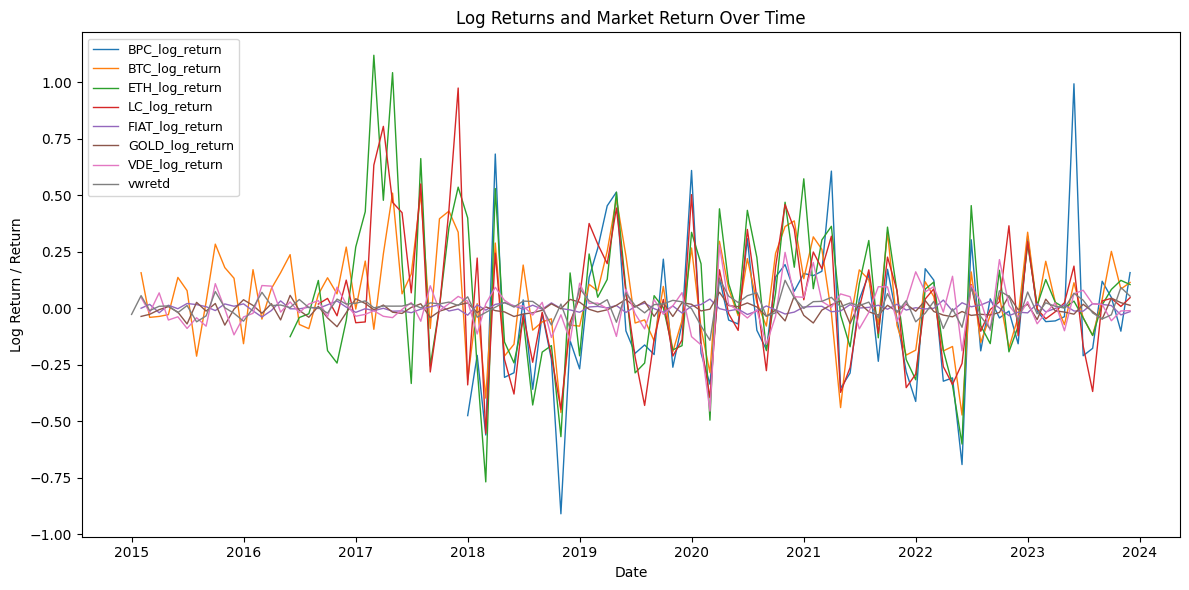

In [25]:
import matplotlib.pyplot as plt

# Ensure 'date' column exists for x-axis
if 'date' not in merged.columns:
    merged['date'] = pd.to_datetime(merged[['year', 'month']].assign(day=1))

cols_to_plot = [
    'BPC_log_return',
    'BTC_log_return',
    'ETH_log_return',
    'LC_log_return',
    'FIAT_log_return',
    'GOLD_log_return',
    'VDE_log_return',
    'vwretd'
]

plt.figure(figsize=(12, 6))
for col in cols_to_plot:
    plt.plot(merged['date'], merged[col], label=col, linewidth=1)

plt.xlabel('Date')
plt.ylabel('Log Return / Return')
plt.title('Log Returns and Market Return Over Time')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


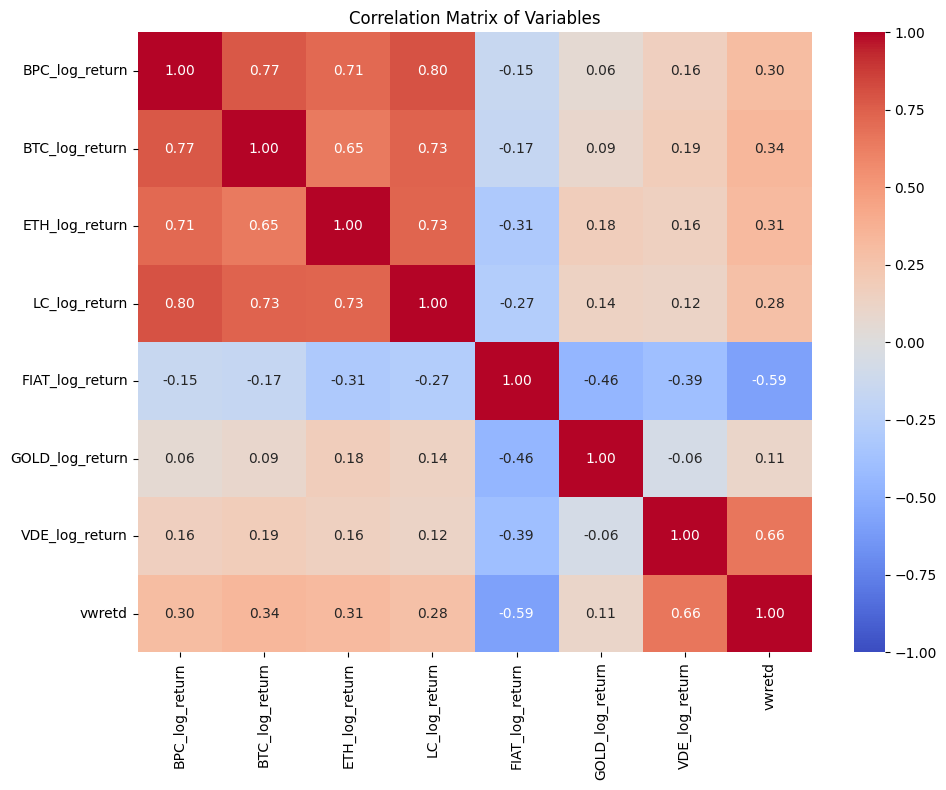

In [26]:
import seaborn as sns

# Compute correlation matrix for numeric columns
corr = merged[cols_to_plot].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()


In [27]:
crypto_cols = ['BTC_log_return', 'ETH_log_return', 'LC_log_return', 'BPC_log_return']

merged_df = merged.melt(
    id_vars=['year','month','FIAT_log_return','GOLD_log_return','VDE_log_return','vwretd' ,'Mkt-RF',	'SMB',	'HML',	'RF'],
    value_vars=crypto_cols,
    var_name='crypto',
    value_name='crypto_log_return'
)

In [28]:
merged_df

,year,month,FIAT_log_return,GOLD_log_return,VDE_log_return,vwretd,Mkt-RF,SMB,HML,RF,crypto,crypto_log_return
0,2015,1,NaN,NaN,NaN,-0.027163,-3.10,-0.59,-3.45,0.00,BTC_log_return,NaN
1,2015,2,0.000092,-0.035984,0.047763,0.055915,6.13,0.61,-1.79,0.00,BTC_log_return,0.157017
2,2015,3,0.017288,-0.026751,-0.019216,-0.010397,-1.11,3.05,-0.38,0.00,BTC_log_return,-0.040278
3,2015,4,-0.020001,-0.006197,0.068133,0.008766,0.59,-2.99,1.80,0.00,BTC_log_return,-0.036039
4,2015,5,0.013457,0.007568,-0.052008,0.010277,1.37,0.95,-1.11,0.00,BTC_log_return,-0.028266
...,...,...,...,...,...,...,...,...,...,...,...,...
427,2023,8,0.020225,-0.014844,0.019281,-0.020605,-2.36,-3.14,-1.15,0.45,BPC_log_return,-0.177101
428,2023,9,0.016816,-0.047756,0.016788,-0.047390,-5.23,-2.51,1.49,0.43,BPC_log_return,0.119415
429,2023,10,0.012074,0.044992,-0.055146,-0.028867,-3.15,-3.86,0.20,0.47,BPC_log_return,0.047946
430,2023,11,-0.029273,0.024670,-0.011910,0.092057,8.88,-0.10,1.67,0.44,BPC_log_return,-0.101327


In [29]:
merged_df = merged_df.dropna()
merged_df

,year,month,FIAT_log_return,GOLD_log_return,VDE_log_return,vwretd,Mkt-RF,SMB,HML,RF,crypto,crypto_log_return
1,2015,2,0.000092,-0.035984,0.047763,0.055915,6.13,0.61,-1.79,0.00,BTC_log_return,0.157017
2,2015,3,0.017288,-0.026751,-0.019216,-0.010397,-1.11,3.05,-0.38,0.00,BTC_log_return,-0.040278
3,2015,4,-0.020001,-0.006197,0.068133,0.008766,0.59,-2.99,1.80,0.00,BTC_log_return,-0.036039
4,2015,5,0.013457,0.007568,-0.052008,0.010277,1.37,0.95,-1.11,0.00,BTC_log_return,-0.028266
5,2015,6,-0.002060,-0.017197,-0.037651,-0.019231,-1.52,2.94,-0.82,0.00,BTC_log_return,0.136275
...,...,...,...,...,...,...,...,...,...,...,...,...
427,2023,8,0.020225,-0.014844,0.019281,-0.020605,-2.36,-3.14,-1.15,0.45,BPC_log_return,-0.177101
428,2023,9,0.016816,-0.047756,0.016788,-0.047390,-5.23,-2.51,1.49,0.43,BPC_log_return,0.119415
429,2023,10,0.012074,0.044992,-0.055146,-0.028867,-3.15,-3.86,0.20,0.47,BPC_log_return,0.047946
430,2023,11,-0.029273,0.024670,-0.011910,0.092057,8.88,-0.10,1.67,0.44,BPC_log_return,-0.101327


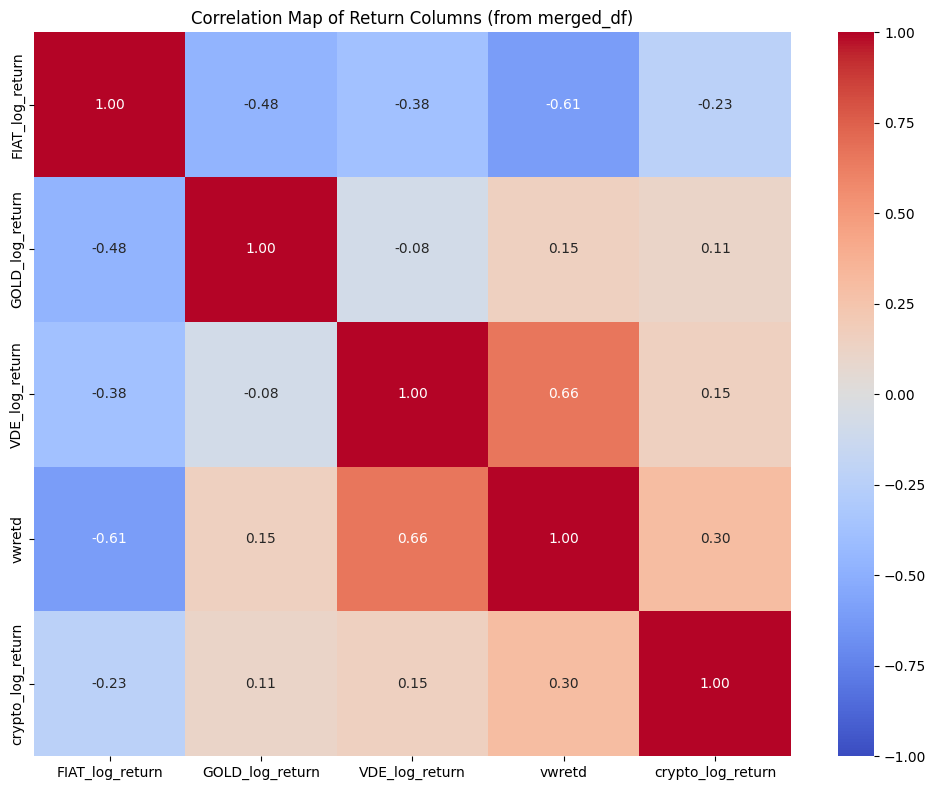

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select all columns that are returns/log returns
return_cols = [
    'FIAT_log_return', 'GOLD_log_return', 'VDE_log_return', 'vwretd', 'crypto_log_return'
]

# Compute correlation matrix of return columns from merged_df
returns_corr = merged_df[return_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(returns_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Map of Return Columns (from merged_df)")
plt.tight_layout()
plt.show()


In [31]:
def add_rolling_features(df, window=6, market_col='vwretd', fama=False):
    df = df.copy().sort_values(['crypto', 'year', 'month'])

    # Compute rolling mean & std per crypto (volatility)
    df['ret_mean_w'] = df.groupby('crypto')['crypto_log_return'] \
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    df['ret_std_w'] = df.groupby('crypto')['crypto_log_return'] \
        .transform(lambda x: x.rolling(window, min_periods=1).std())

    # Z-score of crypto_log_return per crypto within rolling window
    df['ret_zscore_w'] = (
        (df['crypto_log_return'] - df['ret_mean_w']) / df['ret_std_w'].replace(0, 1)
    )

    # Compute rolling means and stds of market proxies
    proxy_cols = ['FIAT_log_return', 'GOLD_log_return', 'VDE_log_return', 'vwretd']
    for col in proxy_cols:
        df[f'{col}_mean_w'] = df.groupby('crypto')[col] \
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        df[f'{col}_std_w'] = df.groupby('crypto')[col] \
            .transform(lambda x: x.rolling(window, min_periods=1).std())
        # Add z-score for market proxies
        df[f'{col}_zscore_w'] = (
            (df[col] - df[f'{col}_mean_w']) / df[f'{col}_std_w'].replace(0, 1)
        )

    # If fama flag is True, add Fama-French rolling features
    if fama:
        ff_cols = ['Mkt-RF', 'SMB', 'HML', 'RF']
        for col in ff_cols:
            df[f'{col}_mean_w'] = df.groupby('crypto')[col] \
                .transform(lambda x: x.rolling(window, min_periods=1).mean())
            df[f'{col}_std_w'] = df.groupby('crypto')[col] \
                .transform(lambda x: x.rolling(window, min_periods=1).std())
            df[f'{col}_zscore_w'] = (
                (df[col] - df[f'{col}_mean_w']) / df[f'{col}_std_w'].replace(0, 1)
            )

    # Rolling correlation with market proxy
    df['corr_market_w'] = df.groupby('crypto').apply(
        lambda g: g['crypto_log_return'].rolling(window, min_periods=3).corr(g[market_col])
    ).reset_index(level=0, drop=True)

    # Fill NaNs for first few months
    df = df.fillna(0)

    return df

merged_df = add_rolling_features(merged_df, window=6)

C:\Users\jmani\AppData\Local\Temp\ipykernel_42544\4166820974.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['corr_market_w'] = df.groupby('crypto').apply(


In [32]:
import torch
from torch.utils.data import Dataset, DataLoader

In [33]:
class CryptoDataset(Dataset):
    def __init__(self, df, window=6, market_col='vwretd', feature_cols=None, target_col='crypto_log_return', fama=False):
        """
        df: long-format DataFrame with columns [crypto, date, ... market columns ...]
        window: number of months in the lookback window (t-w to t)
        market_col: which column is treated as the market factor for beta estimation
        feature_cols: list of columns to include as input features
        target_col: column for the crypto return to predict (r_{t+1})
        fama: if True, also include Fama-French factors (Mkt-RF, SMB, HML, RF) as features
        """
        self.df = df.copy().sort_values(['crypto', 'year', 'month'])
        self.window = window
        self.market_col = market_col
        self.target_col = target_col

        # Default set of computed features we always include: only those that involve market_col
        computed_feats = [col for col in [
            'ret_mean_w', 'ret_std_w',
            'FIAT_log_return_mean_w', 'GOLD_log_return_mean_w',
            'VDE_log_return_mean_w', 'vwretd_mean_w',
            'corr_market_w'
        ] if market_col in col]

        # By default, use the input feature_cols, extend with computed features (avoid duplicates)
        base_feats = feature_cols if feature_cols is not None else [
            'crypto_log_return', 'FIAT_log_return', 'GOLD_log_return', 'VDE_log_return', 'vwretd'
        ]
        # Remove any overlap with computed_feats before extending
        base_feats = [col for col in base_feats if col not in computed_feats]
        final_feats = base_feats + computed_feats

        if fama:
            fama_cols = ['Mkt-RF', 'SMB', 'HML', 'RF']
            # Only add fama cols if they exist in df
            fama_cols = [c for c in fama_cols if c in self.df.columns]
            final_feats += fama_cols

        # Remove duplicates, preserve order
        seen = set()
        self.feature_cols = [x for x in final_feats if not (x in seen or seen.add(x))]

        self.target_col = target_col
        self.samples = []

        # Precompute sliding windows for each crypto
        for crypto, g in self.df.groupby('crypto'):
            g = g.reset_index(drop=True)
            for i in range(window, len(g) - 1):  # leave space for t+1 target
                X_window = g.loc[i - window:i - 1, self.feature_cols].values
                y_next = g.loc[i + 0, target_col]  # r_{t+1}
                r_asset_next = g.loc[i + 0, market_col]  # r^{(asset)}_{t+1}
                self.samples.append((crypto, X_window, y_next, r_asset_next))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        crypto, X_window, y_next, r_asset_next = self.samples[idx]

        # Flatten window for MLP input
        X_flat = X_window.flatten().astype(np.float32)

        return {
            'crypto': crypto,
            'X': torch.tensor(X_flat, dtype=torch.float32),
            'y': torch.tensor(y_next, dtype=torch.float32),
            'r_asset': torch.tensor(r_asset_next, dtype=torch.float32)
        }


In [34]:
window = 6
feature_cols = ['crypto_log_return', 'FIAT_log_return', 'GOLD_log_return', 'VDE_log_return', 'vwretd']

dataset = CryptoDataset(merged_df, window=window, feature_cols=feature_cols, market_col='vwretd')

loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Inspect a batch
batch = next(iter(loader))
print(batch['X'].shape)   # [batch_size, window * num_features]
print(batch['y'].shape)   # [batch_size]
print(batch['r_asset'].shape)

torch.Size([32, 36])
torch.Size([32])
torch.Size([32])


In [35]:
import torch.nn as nn

class NeuralBetaMLP(nn.Module):
    """Minimal NN for beta_hat prediction."""
    def __init__(self, in_dim=24, hidden_dim=64, activation="relu"):
        super().__init__()
        self.layer1 = nn.Linear(in_dim, hidden_dim)
        match activation:
            case "relu":
                self.activation = nn.ReLU()
            case "linear":
                self.activation = None
            case "sigmoid":
                self.activation = nn.Sigmoid()
            case "tanh":
                self.activation = nn.Tanh()
            case _:
                raise Exception()
        self.layer2 = nn.Linear(hidden_dim, 1)

    def forward(self, x, m=None):
        op = self.layer1(x)
        if self.activation:
            op = self.activation(op)
        beta = self.layer2(op)
        return beta

    def neural_beta_loss(self,y_true, beta_hat, r_asset):
        """
        y_true: realized crypto return r_{t+1}
        beta_hat: predicted beta (β̂_{t+1})
        r_asset: market return r^{(asset)}_{t+1}
        """
        pred = beta_hat * r_asset
        mse = torch.mean((y_true - pred) ** 2)
        rmse = torch.sqrt(mse + 1e-8)  # add epsilon for stability
        return rmse

In [37]:
# --- Define period-based splits with overlap for lookback context ---
def period_mask(df, start_ym, end_ym):
    """Return boolean mask for year-month period (inclusive)."""
    sy, sm = start_ym
    ey, em = end_ym
    return (
        ((df['year'] > sy) | ((df['year'] == sy) & (df['month'] >= sm))) &
        ((df['year'] < ey) | ((df['year'] == ey) & (df['month'] <= em)))
    )

window = 6  

# Main split ranges
train_start, train_end = (2015, 1), (2019, 12)
val_start, val_end     = (2020, 1), (2021, 12)
test_start, test_end   = (2021, 1), (2023, 12)

# --- Compute masks for all periods ---
train_mask = period_mask(merged_df, train_start, train_end)
val_mask   = period_mask(merged_df, val_start, val_end)
test_mask  = period_mask(merged_df, test_start, test_end)

# --- Extend validation/test splits backward for lookback context ---
def extend_with_context(df, mask, window):
    """Extend period backward by 'window' rows per crypto to provide lookback context."""
    df = df.copy()
    keep_idx = []
    for crypto, g in df.groupby('crypto'):
        idx = g.index[mask.loc[g.index]]  # indices within this crypto’s period
        if len(idx) == 0:
            continue
        start_idx = max(g.index[0], idx[0] - window)
        end_idx = idx[-1]
        keep_idx.extend(list(range(start_idx, end_idx + 1)))
    return df.loc[sorted(set(keep_idx))]

train_df = merged_df.loc[train_mask]
val_df   = extend_with_context(merged_df, val_mask, window)
test_df  = extend_with_context(merged_df, test_mask, window)

# --- Build datasets ---
train_dataset = CryptoDataset(train_df, window=window, market_col='VDE_log_return')
val_dataset   = CryptoDataset(val_df,   window=window, market_col='VDE_log_return')
test_dataset  = CryptoDataset(test_df,  window=window, market_col='VDE_log_return')

# --- Dataloaders ---
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)


In [38]:
import torch.optim as optim

train_losses = []
val_losses = []

input_dim = batch['X'].shape[1]  # dynamically detect correct input width
model = NeuralBetaMLP(in_dim=input_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-5)


epochs = 50
for epoch in range(epochs):
    # ---- Training ----
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        X, y, r_asset = batch['X'], batch['y'], batch['r_asset']
        optimizer.zero_grad()
        beta_hat = model(X)
        loss = model.neural_beta_loss(y, beta_hat, r_asset)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    avg_train_loss = total_loss / len(train_dataset)
    train_losses.append(avg_train_loss)

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            X, y, r_asset = batch['X'], batch['y'], batch['r_asset']
            beta_hat = model(X)
            loss = model.neural_beta_loss(y, beta_hat, r_asset)
            val_loss += loss.item() * X.size(0)
    avg_val_loss = val_loss / len(val_dataset)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Train RMSE: {avg_train_loss:.6f} | Val RMSE: {avg_val_loss:.6f}")


Epoch [1/50] | Train RMSE: 0.332015 | Val RMSE: 0.256652
Epoch [2/50] | Train RMSE: 0.329699 | Val RMSE: 0.256656
Epoch [3/50] | Train RMSE: 0.334947 | Val RMSE: 0.256666
Epoch [4/50] | Train RMSE: 0.334032 | Val RMSE: 0.256674
Epoch [5/50] | Train RMSE: 0.330157 | Val RMSE: 0.256684
Epoch [6/50] | Train RMSE: 0.331393 | Val RMSE: 0.256691
Epoch [7/50] | Train RMSE: 0.334833 | Val RMSE: 0.256699
Epoch [8/50] | Train RMSE: 0.332781 | Val RMSE: 0.256709
Epoch [9/50] | Train RMSE: 0.327744 | Val RMSE: 0.256717
Epoch [10/50] | Train RMSE: 0.327203 | Val RMSE: 0.256724
Epoch [11/50] | Train RMSE: 0.333641 | Val RMSE: 0.256732
Epoch [12/50] | Train RMSE: 0.334380 | Val RMSE: 0.256739
Epoch [13/50] | Train RMSE: 0.334969 | Val RMSE: 0.256745
Epoch [14/50] | Train RMSE: 0.335473 | Val RMSE: 0.256752
Epoch [15/50] | Train RMSE: 0.333503 | Val RMSE: 0.256760
Epoch [16/50] | Train RMSE: 0.333531 | Val RMSE: 0.256767
Epoch [17/50] | Train RMSE: 0.330957 | Val RMSE: 0.256776
Epoch [18/50] | Train R

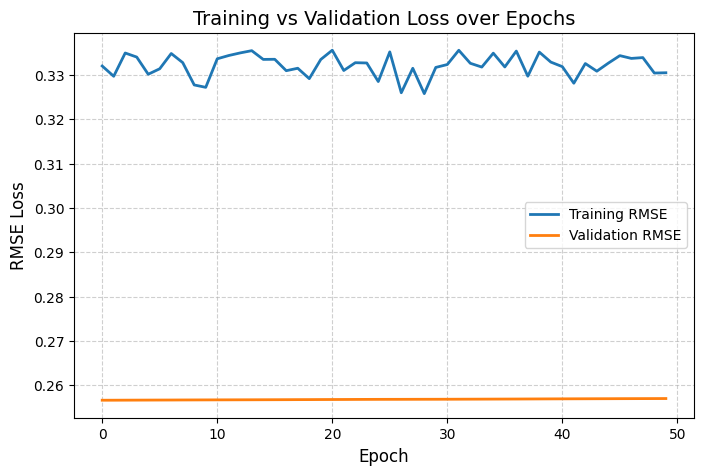

In [39]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Training RMSE', linewidth=2)
plt.plot(val_losses, label='Validation RMSE', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('RMSE Loss', fontsize=12)
plt.title('Training vs Validation Loss over Epochs', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [40]:

import itertools
from torch.utils.data import DataLoader
import torch.optim as optim

# Hyperparameter options
hidden_neurons_options = [4, 8, 16]
learning_rates = [0.001, 0.01, 0.1]
activations = ['linear', 'sigmoid', 'tanh', 'relu']
window_options = [3,6,12]
epochs = 50
batch_size = 32

best_val_loss = float('inf')
best_config = None
results = []

# Grid search over all hyperparameter combinations
for window, hidden_dim, lr, activation in itertools.product(window_options, hidden_neurons_options, learning_rates, activations):
    # Prepare datasets for this window size
    train_dataset = CryptoDataset(merged_df[train_mask], window=window, market_col='VDE_log_return')
    val_dataset   = CryptoDataset(merged_df[val_mask],   window=window, market_col='VDE_log_return')
    test_dataset  = CryptoDataset(merged_df[test_mask],  window=window, market_col='VDE_log_return')
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Dynamically detect input dimension from one batch
    for batch in train_loader:
        input_dim = batch['X'].shape[1]
        break

    # --- Use student's version of NeuralBetaMLP ---
    # It must accept in_dim, hidden_dim, activation as arguments.
    model = NeuralBetaMLP(
        in_dim=input_dim,
        hidden_dim=hidden_dim,
        activation=activation
    )
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            X, y, r_asset = batch['X'], batch['y'], batch['r_asset']
            optimizer.zero_grad()
            beta_hat = model(X)
            loss = model.neural_beta_loss(y, beta_hat, r_asset)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X.size(0)
        avg_train_loss = total_loss / len(train_dataset)
        train_losses.append(avg_train_loss)

        # ---- Validation ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                X, y, r_asset = batch['X'], batch['y'], batch['r_asset']
                beta_hat = model(X)
                loss = model.neural_beta_loss(y, beta_hat, r_asset)
                val_loss += loss.item() * X.size(0)
        avg_val_loss = val_loss / len(val_dataset)
        val_losses.append(avg_val_loss)

    config = {
        "window": window,
        "hidden_dim": hidden_dim,
        "learning_rate": lr,
        "activation": activation
    }
    min_val_loss = min(val_losses)
    results.append({"config": config, "min_val_loss": min_val_loss})
    print(f"[{config}] --> Min Val RMSE: {min_val_loss:.6f}")
    if min_val_loss < best_val_loss:
        best_val_loss = min_val_loss
        best_config = config

print("Best hyperparameter config:", best_config, "with validation RMSE:", best_val_loss)










[{'window': 3, 'hidden_dim': 4, 'learning_rate': 0.001, 'activation': 'linear'}] --> Min Val RMSE: 0.230006
[{'window': 3, 'hidden_dim': 4, 'learning_rate': 0.001, 'activation': 'sigmoid'}] --> Min Val RMSE: 0.243560
[{'window': 3, 'hidden_dim': 4, 'learning_rate': 0.001, 'activation': 'tanh'}] --> Min Val RMSE: 0.253145
[{'window': 3, 'hidden_dim': 4, 'learning_rate': 0.001, 'activation': 'relu'}] --> Min Val RMSE: 0.233127
[{'window': 3, 'hidden_dim': 4, 'learning_rate': 0.01, 'activation': 'linear'}] --> Min Val RMSE: 0.240403
[{'window': 3, 'hidden_dim': 4, 'learning_rate': 0.01, 'activation': 'sigmoid'}] --> Min Val RMSE: 0.247043
[{'window': 3, 'hidden_dim': 4, 'learning_rate': 0.01, 'activation': 'tanh'}] --> Min Val RMSE: 0.248204
[{'window': 3, 'hidden_dim': 4, 'learning_rate': 0.01, 'activation': 'relu'}] --> Min Val RMSE: 0.240136
[{'window': 3, 'hidden_dim': 4, 'learning_rate': 0.1, 'activation': 'linear'}] --> Min Val RMSE: 0.239425
[{'window': 3, 'hidden_dim': 4, 'learnin

In [64]:


# 1. Set the best hyperparameters
def fit_and_predict_beta(market_col,fama = False):
    window = best_config["window"]
    best_hidden_dim = best_config["hidden_dim"]
    best_lr = best_config["learning_rate"]
    best_activation = best_config["activation"]

    train_dataset = CryptoDataset(merged_df[train_mask], window=window, market_col=market_col, fama=fama)
    val_dataset   = CryptoDataset(merged_df[val_mask],   window=window, market_col=market_col, fama=fama)
    test_dataset  = CryptoDataset(merged_df[test_mask],  window=window, market_col=market_col, fama=fama)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    for batch in train_loader:
        input_dim = batch['X'].shape[1]
        break

    # Create DataLoader for test dataset
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Refit the model
    model = NeuralBetaMLP(in_dim=input_dim, hidden_dim=best_hidden_dim, activation=best_activation)
    optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
    num_epochs = 30  # You may adjust based on your previous experiments

    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader:
            X, y, r_asset = batch['X'], batch['y'], batch['r_asset']
            optimizer.zero_grad()
            beta_hat = model(X)
            loss = model.neural_beta_loss(y, beta_hat, r_asset)
            loss.backward()
            optimizer.step()

    # Predict beta on the test set
    model.eval()
    all_beta_pred = []
    with torch.no_grad():
        for batch in test_loader:
            X, y, r_asset = batch['X'], batch['y'], batch['r_asset']
            beta_hat = model(X)
            all_beta_pred.append(beta_hat.cpu())
    all_beta_pred = torch.cat(all_beta_pred, dim=0).numpy()

    # (Optional) Store or print the beta predictions
    print("Predicted beta on test set:", all_beta_pred)
    return all_beta_pred


In [65]:
all_beta_pred = fit_and_predict_beta(market_col='VDE_log_return')

Predicted beta on test set: [[-0.15984029]
 [-0.17870136]
 [-0.1567078 ]
 [-0.14464697]
 [-0.15550436]
 [-0.16648373]
 [-0.15248038]
 [-0.15617251]
 [-0.15596947]
 [-0.15057516]
 [-0.13751177]
 [-0.15019897]
 [-0.15754434]
 [-0.14820689]
 [-0.1427638 ]
 [-0.1331136 ]
 [-0.16108531]
 [-0.15220557]
 [-0.1593821 ]
 [-0.15511966]
 [-0.15087901]
 [-0.15164956]
 [-0.1665385 ]
 [-0.16282263]
 [-0.16050158]
 [-0.15645646]
 [-0.15699366]
 [-0.18816075]
 [-0.16257058]
 [-0.15040112]
 [-0.15671599]
 [-0.16147907]
 [-0.16503367]
 [-0.16195446]
 [-0.14585143]
 [-0.14790168]
 [-0.16224393]
 [-0.16838448]
 [-0.15746291]
 [-0.16322799]
 [-0.15794061]
 [-0.1529425 ]
 [-0.14509524]
 [-0.15187219]
 [-0.15536074]
 [-0.15096319]
 [-0.14843902]
 [-0.14191149]
 [-0.16039565]
 [-0.15207562]
 [-0.15724522]
 [-0.15708745]
 [-0.14711472]
 [-0.15325254]
 [-0.16815954]
 [-0.1638365 ]
 [-0.16866523]
 [-0.16268484]
 [-0.15802626]
 [-0.1617668 ]
 [-0.1552257 ]
 [-0.15116453]
 [-0.15570685]
 [-0.16662051]
 [-0.1646503

In [50]:
test_df = merged_df[test_mask]

In [51]:
# Only assign to the rows that match the number of beta predictions
test_df.loc[test_df.index[len(test_df)-len(all_beta_pred):], 'energy beta'] = all_beta_pred


C:\Users\jmani\AppData\Local\Temp\ipykernel_42544\3248814695.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.loc[test_df.index[len(test_df)-len(all_beta_pred):], 'energy beta'] = all_beta_pred


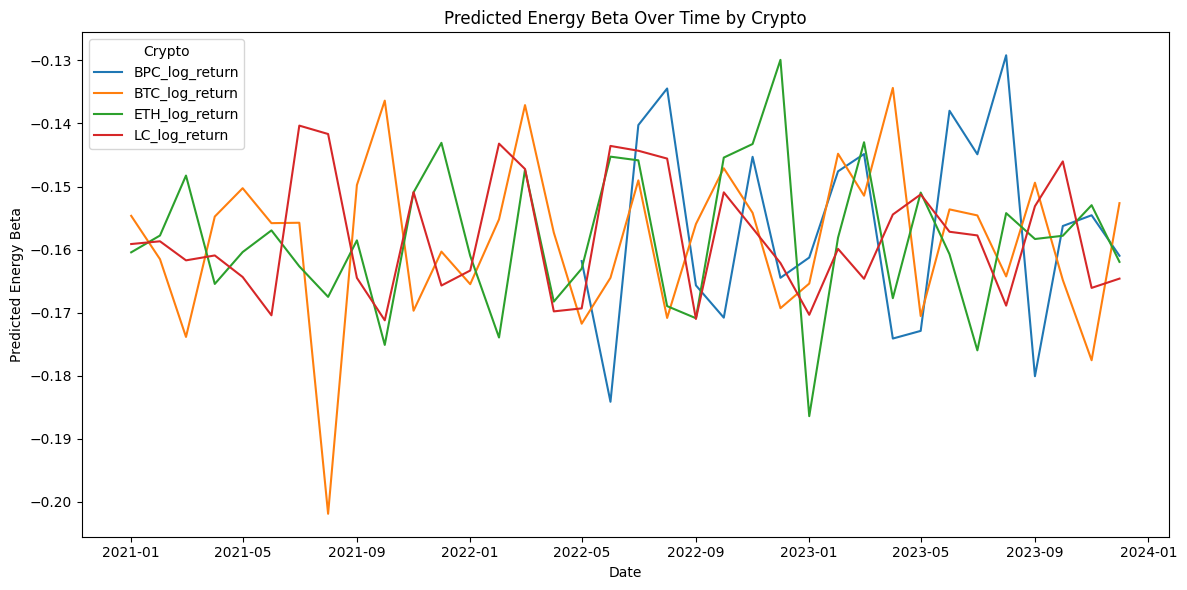

In [53]:
import matplotlib.pyplot as plt

# Plot energy beta for each crypto in the test set
plt.figure(figsize=(12, 6))
for crypto in test_df['crypto'].unique():
    df_crypto = test_df[test_df['crypto'] == crypto]
    # Create a time axis: convert year, month to pandas datetime
    datetimes = pd.to_datetime(df_crypto['year'].astype(int).astype(str) + '-' + df_crypto['month'].astype(int).astype(str) + '-01')
    plt.plot(datetimes, df_crypto['energy beta'], label=crypto)

plt.xlabel('Date')
plt.ylabel('Predicted Energy Beta')
plt.title('Predicted Energy Beta Over Time by Crypto')
plt.legend(title='Crypto')
plt.tight_layout()
plt.show()


In [54]:
# Describe statistics for all different crypto values in the test set
for crypto in test_df['crypto'].unique():
    print(f"\nStatistics for crypto: {crypto}")
    display(test_df[test_df['crypto'] == crypto].describe())



Statistics for crypto: BPC_log_return


,year,month,FIAT_log_return,GOLD_log_return,VDE_log_return,vwretd,Mkt-RF,SMB,HML,RF,...,GOLD_log_return_std_w,GOLD_log_return_zscore_w,VDE_log_return_mean_w,VDE_log_return_std_w,VDE_log_return_zscore_w,vwretd_mean_w,vwretd_std_w,vwretd_zscore_w,corr_market_w,energy beta
count,36.000000,36.00000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,20.000000
mean,2022.000000,6.50000,0.001798,-0.007534,0.025029,0.007062,0.590556,-0.330278,1.116944,0.173333,...,0.031062,0.012593,0.029778,0.088793,-0.042928,0.008101,0.048198,-0.105205,0.569855,-0.156569
std,0.828079,3.50102,0.016474,0.030651,0.085326,0.050130,5.091053,3.015145,4.894042,0.186440,...,0.009980,0.851425,0.029942,0.030823,0.828734,0.018664,0.018072,0.878720,0.218048,0.015621
min,2021.000000,1.00000,-0.032649,-0.067999,-0.188058,-0.091323,-9.410000,-5.930000,-9.050000,0.000000,...,0.007771,-1.465710,-0.029250,0.039011,-1.789893,-0.037775,0.014626,-1.800565,-0.221583,-0.184116
25%,2021.000000,3.75000,-0.011972,-0.029778,-0.019100,-0.025716,-2.715000,-2.375000,-1.052500,0.000000,...,0.024760,-0.582799,0.008333,0.067610,-0.689844,0.000903,0.037811,-0.795009,0.493270,-0.166943
50%,2022.000000,6.50000,0.001732,-0.014318,0.024719,0.010402,0.980000,-0.540000,0.190000,0.070000,...,0.032784,-0.078060,0.024725,0.078911,-0.001744,0.011814,0.047910,-0.074285,0.597747,-0.158614
75%,2023.000000,9.25000,0.014464,0.017793,0.074164,0.038766,3.585000,1.625000,4.267500,0.352500,...,0.038269,0.721323,0.047336,0.110583,0.621813,0.023151,0.058100,0.553200,0.722109,-0.144875
max,2023.000000,12.00000,0.036373,0.055205,0.215278,0.092057,9.570000,7.140000,12.860000,0.470000,...,0.045360,2.000295,0.097271,0.152067,1.357933,0.046014,0.081964,1.499177,0.890384,-0.129188



Statistics for crypto: BTC_log_return


,year,month,FIAT_log_return,GOLD_log_return,VDE_log_return,vwretd,Mkt-RF,SMB,HML,RF,...,GOLD_log_return_std_w,GOLD_log_return_zscore_w,VDE_log_return_mean_w,VDE_log_return_std_w,VDE_log_return_zscore_w,vwretd_mean_w,vwretd_std_w,vwretd_zscore_w,corr_market_w,energy beta
count,36.000000,36.00000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,2022.000000,6.50000,0.001798,-0.007534,0.025029,0.007062,0.590556,-0.330278,1.116944,0.173333,...,0.031062,0.012593,0.029778,0.088793,-0.042928,0.008101,0.048198,-0.105205,0.495698,-0.158486
std,0.828079,3.50102,0.016474,0.030651,0.085326,0.050130,5.091053,3.015145,4.894042,0.186440,...,0.009980,0.851425,0.029942,0.030823,0.828734,0.018664,0.018072,0.878720,0.226650,0.012850
min,2021.000000,1.00000,-0.032649,-0.067999,-0.188058,-0.091323,-9.410000,-5.930000,-9.050000,0.000000,...,0.007771,-1.465710,-0.029250,0.039011,-1.789893,-0.037775,0.014626,-1.800565,-0.030122,-0.201873
25%,2021.000000,3.75000,-0.011972,-0.029778,-0.019100,-0.025716,-2.715000,-2.375000,-1.052500,0.000000,...,0.024760,-0.582799,0.008333,0.067610,-0.689844,0.000903,0.037811,-0.795009,0.378997,-0.165400
50%,2022.000000,6.50000,0.001732,-0.014318,0.024719,0.010402,0.980000,-0.540000,0.190000,0.070000,...,0.032784,-0.078060,0.024725,0.078911,-0.001744,0.011814,0.047910,-0.074285,0.488366,-0.155769
75%,2023.000000,9.25000,0.014464,0.017793,0.074164,0.038766,3.585000,1.625000,4.267500,0.352500,...,0.038269,0.721323,0.047336,0.110583,0.621813,0.023151,0.058100,0.553200,0.671978,-0.151150
max,2023.000000,12.00000,0.036373,0.055205,0.215278,0.092057,9.570000,7.140000,12.860000,0.470000,...,0.045360,2.000295,0.097271,0.152067,1.357933,0.046014,0.081964,1.499177,0.879001,-0.134364



Statistics for crypto: ETH_log_return


,year,month,FIAT_log_return,GOLD_log_return,VDE_log_return,vwretd,Mkt-RF,SMB,HML,RF,...,GOLD_log_return_std_w,GOLD_log_return_zscore_w,VDE_log_return_mean_w,VDE_log_return_std_w,VDE_log_return_zscore_w,vwretd_mean_w,vwretd_std_w,vwretd_zscore_w,corr_market_w,energy beta
count,36.000000,36.00000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,2022.000000,6.50000,0.001798,-0.007534,0.025029,0.007062,0.590556,-0.330278,1.116944,0.173333,...,0.031062,0.012593,0.029778,0.088793,-0.042928,0.008101,0.048198,-0.105205,0.518908,-0.158278
std,0.828079,3.50102,0.016474,0.030651,0.085326,0.050130,5.091053,3.015145,4.894042,0.186440,...,0.009980,0.851425,0.029942,0.030823,0.828734,0.018664,0.018072,0.878720,0.259767,0.011546
min,2021.000000,1.00000,-0.032649,-0.067999,-0.188058,-0.091323,-9.410000,-5.930000,-9.050000,0.000000,...,0.007771,-1.465710,-0.029250,0.039011,-1.789893,-0.037775,0.014626,-1.800565,-0.112630,-0.186397
25%,2021.000000,3.75000,-0.011972,-0.029778,-0.019100,-0.025716,-2.715000,-2.375000,-1.052500,0.000000,...,0.024760,-0.582799,0.008333,0.067610,-0.689844,0.000903,0.037811,-0.795009,0.396481,-0.165950
50%,2022.000000,6.50000,0.001732,-0.014318,0.024719,0.010402,0.980000,-0.540000,0.190000,0.070000,...,0.032784,-0.078060,0.024725,0.078911,-0.001744,0.011814,0.047910,-0.074285,0.610440,-0.158423
75%,2023.000000,9.25000,0.014464,0.017793,0.074164,0.038766,3.585000,1.625000,4.267500,0.352500,...,0.038269,0.721323,0.047336,0.110583,0.621813,0.023151,0.058100,0.553200,0.672428,-0.150258
max,2023.000000,12.00000,0.036373,0.055205,0.215278,0.092057,9.570000,7.140000,12.860000,0.470000,...,0.045360,2.000295,0.097271,0.152067,1.357933,0.046014,0.081964,1.499177,0.950265,-0.129916



Statistics for crypto: LC_log_return


,year,month,FIAT_log_return,GOLD_log_return,VDE_log_return,vwretd,Mkt-RF,SMB,HML,RF,...,GOLD_log_return_std_w,GOLD_log_return_zscore_w,VDE_log_return_mean_w,VDE_log_return_std_w,VDE_log_return_zscore_w,vwretd_mean_w,vwretd_std_w,vwretd_zscore_w,corr_market_w,energy beta
count,36.000000,36.00000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,2022.000000,6.50000,0.001798,-0.007534,0.025029,0.007062,0.590556,-0.330278,1.116944,0.173333,...,0.031062,0.012593,0.029778,0.088793,-0.042928,0.008101,0.048198,-0.105205,0.576335,-0.158067
std,0.828079,3.50102,0.016474,0.030651,0.085326,0.050130,5.091053,3.015145,4.894042,0.186440,...,0.009980,0.851425,0.029942,0.030823,0.828734,0.018664,0.018072,0.878720,0.213454,0.009552
min,2021.000000,1.00000,-0.032649,-0.067999,-0.188058,-0.091323,-9.410000,-5.930000,-9.050000,0.000000,...,0.007771,-1.465710,-0.029250,0.039011,-1.789893,-0.037775,0.014626,-1.800565,0.169005,-0.171204
25%,2021.000000,3.75000,-0.011972,-0.029778,-0.019100,-0.025716,-2.715000,-2.375000,-1.052500,0.000000,...,0.024760,-0.582799,0.008333,0.067610,-0.689844,0.000903,0.037811,-0.795009,0.400757,-0.164885
50%,2022.000000,6.50000,0.001732,-0.014318,0.024719,0.010402,0.980000,-0.540000,0.190000,0.070000,...,0.032784,-0.078060,0.024725,0.078911,-0.001744,0.011814,0.047910,-0.074285,0.613624,-0.159494
75%,2023.000000,9.25000,0.014464,0.017793,0.074164,0.038766,3.585000,1.625000,4.267500,0.352500,...,0.038269,0.721323,0.047336,0.110583,0.621813,0.023151,0.058100,0.553200,0.760378,-0.150908
max,2023.000000,12.00000,0.036373,0.055205,0.215278,0.092057,9.570000,7.140000,12.860000,0.470000,...,0.045360,2.000295,0.097271,0.152067,1.357933,0.046014,0.081964,1.499177,0.891665,-0.140340


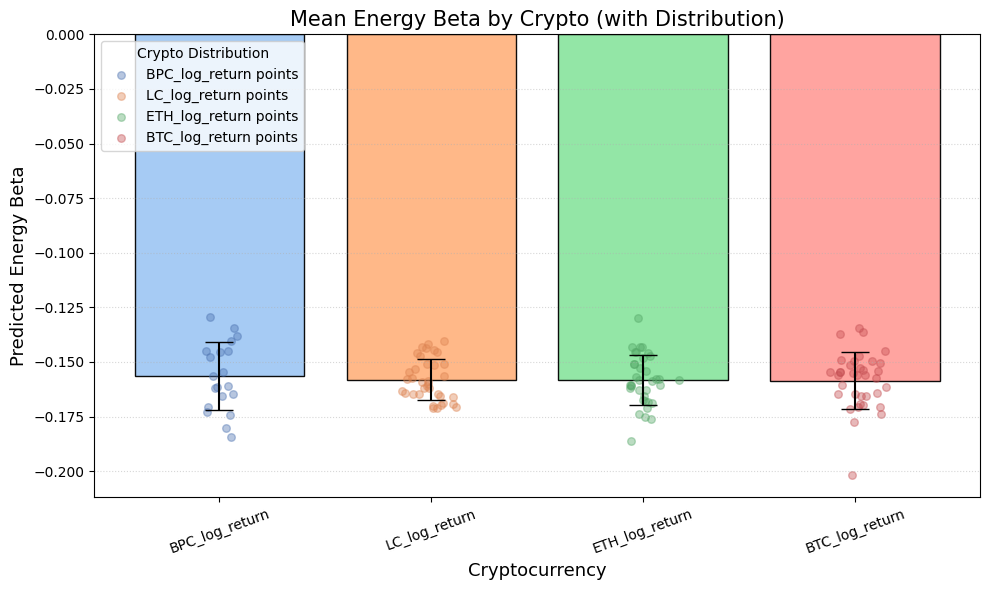

In [55]:
import numpy as np

import seaborn as sns

# Group by crypto and compute mean and std of energy beta
beta_stats = test_df.groupby('crypto', as_index=False)['energy beta'].agg(['mean', 'std', 'count'])
beta_stats.reset_index(inplace=True)
beta_stats = beta_stats.sort_values(by='mean', ascending=False)

# Plot with error bars, improved design
plt.figure(figsize=(10, 6))
bar = plt.bar(
    beta_stats['crypto'], 
    beta_stats['mean'], 
    yerr=beta_stats['std'], 
    capsize=10, 
    color=sns.color_palette("pastel", n_colors=len(beta_stats)),
    edgecolor='black',
    alpha=0.95
)

# Overlay points showing distribution for each token
for i, crypto in enumerate(beta_stats['crypto']):
    ys = test_df[test_df['crypto'] == crypto]['energy beta']
    x_jittered = np.random.normal(loc=i, scale=0.06, size=len(ys))
    plt.scatter(x_jittered, ys, alpha=0.4, color=sns.color_palette("deep")[i % 10], s=30, label=f'{crypto} points')

plt.xlabel('Cryptocurrency', fontsize=13)
plt.ylabel('Predicted Energy Beta', fontsize=13)
plt.title('Mean Energy Beta by Crypto (with Distribution)', fontsize=15)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.xticks(rotation=20)
# Only show legend for scatter once per crypto
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', frameon=True, title='Crypto Distribution')
plt.tight_layout()
plt.show()


# fiat

In [56]:
crypto_beta = fit_and_predict_beta(market_col='FIAT_log_return')

Predicted beta on test set: [[-0.82430786]
 [-0.82775146]
 [-0.8234551 ]
 [-0.830832  ]
 [-0.79573387]
 [-0.8121564 ]
 [-0.816713  ]
 [-0.82370675]
 [-0.80382776]
 [-0.81661963]
 [-0.8025428 ]
 [-0.795399  ]
 [-0.7944561 ]
 [-0.80778176]
 [-0.8064127 ]
 [-0.7843239 ]
 [-0.79942846]
 [-0.7973131 ]
 [-0.8210574 ]
 [-0.8102776 ]
 [-0.8201134 ]
 [-0.80345047]
 [-0.8174783 ]
 [-0.8119733 ]
 [-0.82529914]
 [-0.81704295]
 [-0.8114872 ]
 [-0.83063745]
 [-0.83077776]
 [-0.8439758 ]
 [-0.80081713]
 [-0.80660677]
 [-0.82704127]
 [-0.8263187 ]
 [-0.8177105 ]
 [-0.81060964]
 [-0.7974197 ]
 [-0.82161623]
 [-0.82337534]
 [-0.82725984]
 [-0.81137884]
 [-0.82311076]
 [-0.80560696]
 [-0.80013454]
 [-0.8008132 ]
 [-0.8066584 ]
 [-0.8074665 ]
 [-0.7939161 ]
 [-0.8051812 ]
 [-0.80385697]
 [-0.8154354 ]
 [-0.81202275]
 [-0.81644976]
 [-0.80644673]
 [-0.81342804]
 [-0.8166208 ]
 [-0.82980597]
 [-0.8220631 ]
 [-0.8216204 ]
 [-0.82086694]
 [-0.8206657 ]
 [-0.81584966]
 [-0.8064435 ]
 [-0.81050014]
 [-0.8403186

In [58]:
test_df.loc[test_df.index[len(test_df)-len(all_beta_pred):], 'fiat beta'] = crypto_beta


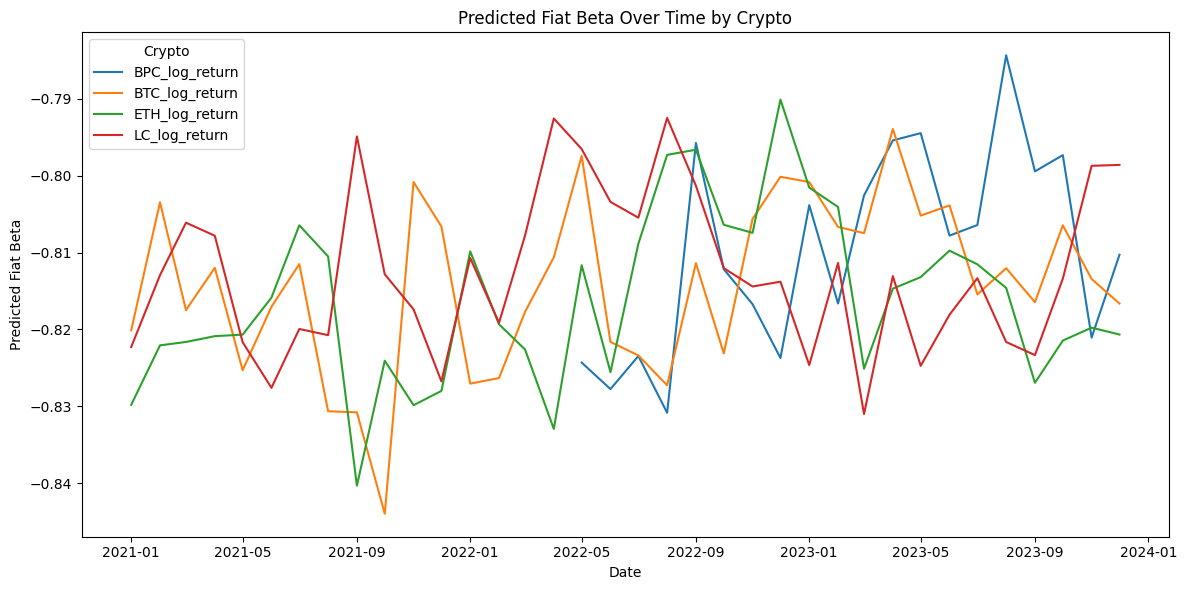

In [59]:
import matplotlib.pyplot as plt

# Plot fiat beta for each crypto in the test set
plt.figure(figsize=(12, 6))
for crypto in test_df['crypto'].unique():
    df_crypto = test_df[test_df['crypto'] == crypto]
    # Create a time axis: convert year, month to pandas datetime
    datetimes = pd.to_datetime(df_crypto['year'].astype(int).astype(str) + '-' + df_crypto['month'].astype(int).astype(str) + '-01')
    plt.plot(datetimes, df_crypto['fiat beta'], label=crypto)

plt.xlabel('Date')
plt.ylabel('Predicted Fiat Beta')
plt.title('Predicted Fiat Beta Over Time by Crypto')
plt.legend(title='Crypto')
plt.tight_layout()
plt.show()

In [60]:
# Describe the fiat beta across crypto

# Calculate descriptive statistics for fiat beta by crypto in the test set
fiat_beta_stats = test_df.groupby('crypto')['fiat beta'].describe()
print("Fiat Beta Descriptive Statistics by Crypto:")
print(fiat_beta_stats)

# Check the average fiat beta over time for each crypto
avg_fiat_beta_over_time = test_df.groupby(['year', 'month', 'crypto'])['fiat beta'].mean().unstack()
print("\nAverage Fiat Beta Over Time (first few rows):")
print(avg_fiat_beta_over_time.head())

# Simple overall summary
print("\nOverall Mean Fiat Beta by Crypto:")
print(test_df.groupby('crypto')['fiat beta'].mean())

print("\nOverall Std Fiat Beta by Crypto:")
print(test_df.groupby('crypto')['fiat beta'].std())


Fiat Beta Descriptive Statistics by Crypto:
                count      mean       std       min       25%       50%  \
crypto                                                                    
BPC_log_return   20.0 -0.809705  0.013056 -0.830832 -0.821657 -0.809030   
BTC_log_return   36.0 -0.814154  0.010980 -0.843976 -0.821990 -0.812725   
ETH_log_return   36.0 -0.816159  0.010970 -0.840319 -0.822960 -0.817586   
LC_log_return    36.0 -0.812562  0.010386 -0.830998 -0.820960 -0.813193   

                     75%       max  
crypto                              
BPC_log_return -0.798900 -0.784324  
BTC_log_return -0.806237 -0.793916  
ETH_log_return -0.809517 -0.790086  
LC_log_return  -0.805942 -0.792474  

Average Fiat Beta Over Time (first few rows):
crypto      BPC_log_return  BTC_log_return  ETH_log_return  LC_log_return
year month                                                               
2021 1                 NaN       -0.820113       -0.829806      -0.822288
     2        

# equity

In [61]:
equity_beta = fit_and_predict_beta(market_col="vwretd")

Predicted beta on test set: [[0.05532376]
 [0.04701526]
 [0.05378686]
 [0.08414125]
 [0.05018646]
 [0.04396772]
 [0.05606717]
 [0.05650803]
 [0.04793584]
 [0.06391914]
 [0.06243315]
 [0.04339636]
 [0.0345483 ]
 [0.06342283]
 [0.06646888]
 [0.06321609]
 [0.04998925]
 [0.03055343]
 [0.06449907]
 [0.04424538]
 [0.05274155]
 [0.0537137 ]
 [0.04413185]
 [0.04572772]
 [0.06221706]
 [0.05466862]
 [0.05399562]
 [0.03397083]
 [0.03696612]
 [0.09031272]
 [0.04975418]
 [0.04434309]
 [0.04963404]
 [0.06267387]
 [0.06972064]
 [0.06271651]
 [0.04100092]
 [0.04877787]
 [0.05717069]
 [0.04966824]
 [0.05039966]
 [0.06785271]
 [0.05579221]
 [0.04259551]
 [0.04371793]
 [0.06039552]
 [0.05920257]
 [0.06042233]
 [0.05289631]
 [0.03891043]
 [0.06104614]
 [0.0447881 ]
 [0.05204201]
 [0.05717746]
 [0.03685063]
 [0.04870458]
 [0.05726232]
 [0.04857001]
 [0.06114058]
 [0.05425127]
 [0.04867637]
 [0.06023602]
 [0.05526946]
 [0.04350805]
 [0.06603172]
 [0.04757859]
 [0.05599648]
 [0.06888768]
 [0.05633409]
 [0.04

In [62]:
test_df.loc[test_df.index[len(test_df)-len(all_beta_pred):], 'equity beta'] = equity_beta


C:\Users\jmani\AppData\Local\Temp\ipykernel_42544\838610487.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.loc[test_df.index[len(test_df)-len(all_beta_pred):], 'equity beta'] = equity_beta


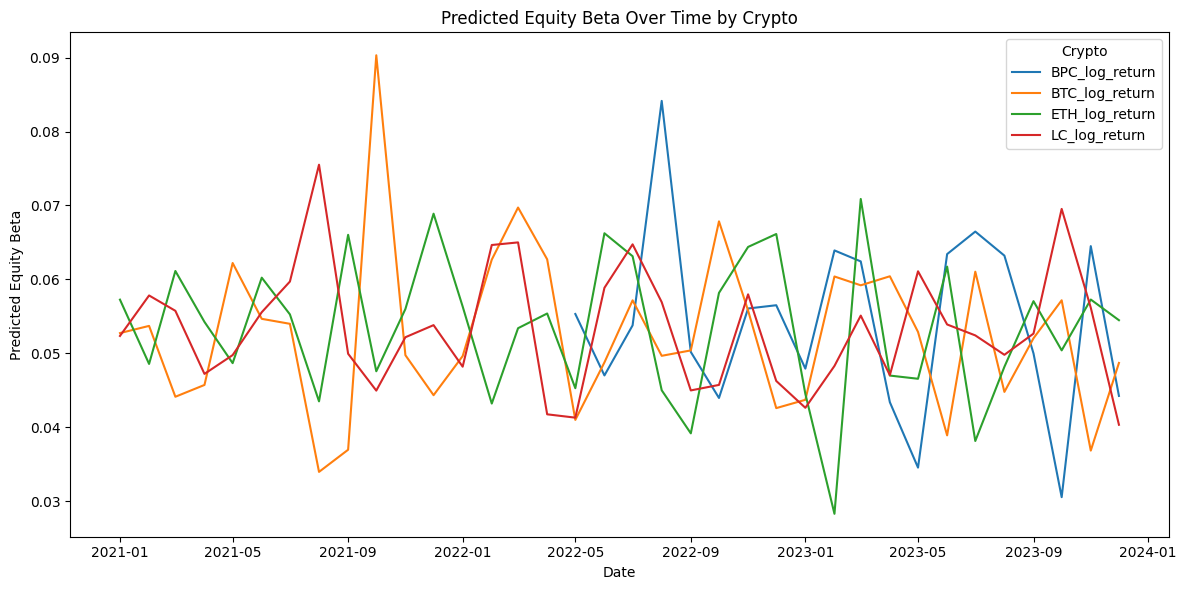

In [63]:
import matplotlib.pyplot as plt

# Plot equity beta for each crypto in the test set
plt.figure(figsize=(12, 6))
for crypto in test_df['crypto'].unique():
    df_crypto = test_df[test_df['crypto'] == crypto]
    # Create a time axis: convert year, month to pandas datetime
    datetimes = pd.to_datetime(df_crypto['year'].astype(int).astype(str) + '-' + df_crypto['month'].astype(int).astype(str) + '-01')
    plt.plot(datetimes, df_crypto['equity beta'], label=crypto)

plt.xlabel('Date')
plt.ylabel('Predicted Equity Beta')
plt.title('Predicted Equity Beta Over Time by Crypto')
plt.legend(title='Crypto')
plt.tight_layout()
plt.show()

# FAMA

In [66]:
all_beta_pred = fit_and_predict_beta(market_col='VDE_log_return',fama=True)

Predicted beta on test set: [[-0.1867437 ]
 [-0.15411079]
 [-0.2217198 ]
 [-0.12945446]
 [-0.14486584]
 [-0.20185122]
 [-0.20332393]
 [-0.16028842]
 [-0.17971501]
 [-0.2065936 ]
 [-0.17168346]
 [-0.04839242]
 [-0.1308715 ]
 [-0.10836794]
 [-0.14211282]
 [ 0.00423654]
 [-0.14421853]
 [-0.20588303]
 [-0.01416031]
 [-0.23095557]
 [-0.27934796]
 [-0.07500982]
 [-0.16560513]
 [-0.20006815]
 [-0.0514453 ]
 [-0.17004448]
 [-0.15680689]
 [-0.27804598]
 [-0.26790637]
 [-0.06692433]
 [-0.01318729]
 [-0.07270374]
 [-0.18718567]
 [-0.14889568]
 [-0.21797505]
 [-0.13608882]
 [-0.14628515]
 [-0.19987193]
 [-0.20285675]
 [-0.16215736]
 [-0.17851487]
 [-0.20515797]
 [-0.17302409]
 [-0.04721839]
 [-0.13061532]
 [-0.10992264]
 [-0.14384514]
 [ 0.0041128 ]
 [-0.14405182]
 [-0.20480889]
 [-0.01495541]
 [-0.23123112]
 [-0.27875045]
 [-0.0745459 ]
 [-0.16683212]
 [-0.19911873]
 [-0.05167426]
 [-0.17010003]
 [-0.15301105]
 [-0.2743348 ]
 [-0.27269107]
 [-0.07744553]
 [-0.011049  ]
 [-0.07285916]
 [-0.1842859

In [ ]:
test_df.loc[test_df.index[len(test_df)-len(all_beta_pred):], 'energy beta fama'] = all_beta_pred


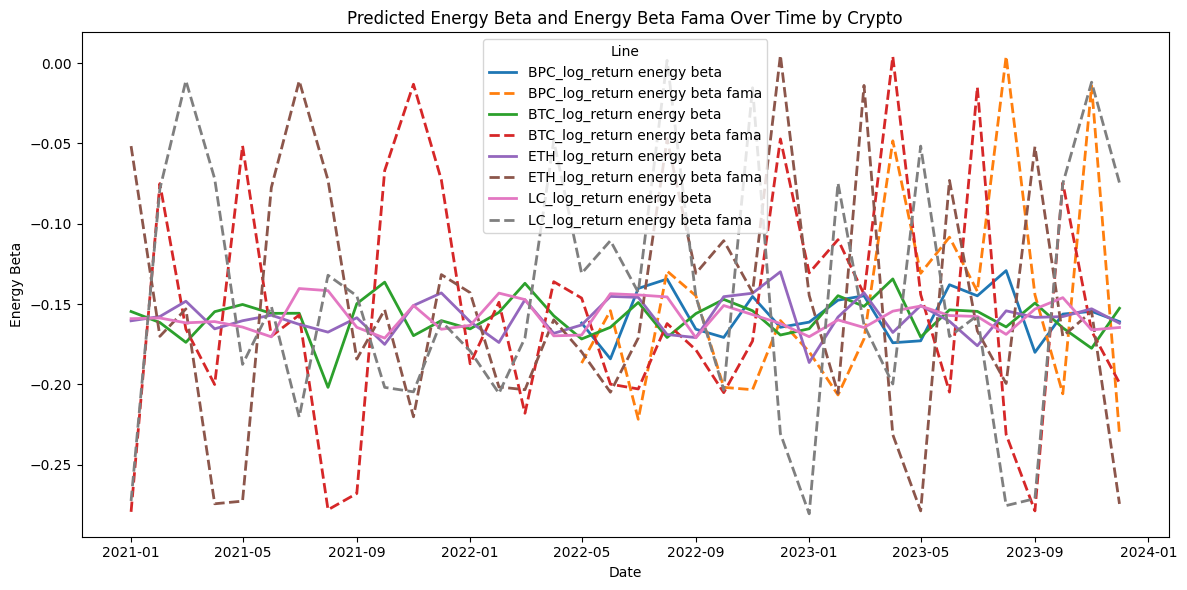

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for crypto in test_df['crypto'].unique():
    df_crypto = test_df[test_df['crypto'] == crypto]
    datetimes = pd.to_datetime(df_crypto['year'].astype(int).astype(str) + '-' + df_crypto['month'].astype(int).astype(str) + '-01')
    plt.plot(datetimes, df_crypto['energy beta'], label=f"{crypto} energy beta", linestyle='-', linewidth=2)
    plt.plot(datetimes, df_crypto['energy beta fama'], label=f"{crypto} energy beta fama", linestyle='--', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Energy Beta')
plt.title('Predicted Energy Beta and Energy Beta Fama Over Time by Crypto')
plt.legend(title='Line')
plt.tight_layout()
plt.show()


In [ ]:
all_beta_pred = fit_and_predict_beta(market_col='FIAT_log_return',fama=True)

In [ ]:
test_df.loc[test_df.index[len(test_df)-len(all_beta_pred):], 'fiat beta fama'] = all_beta_pred


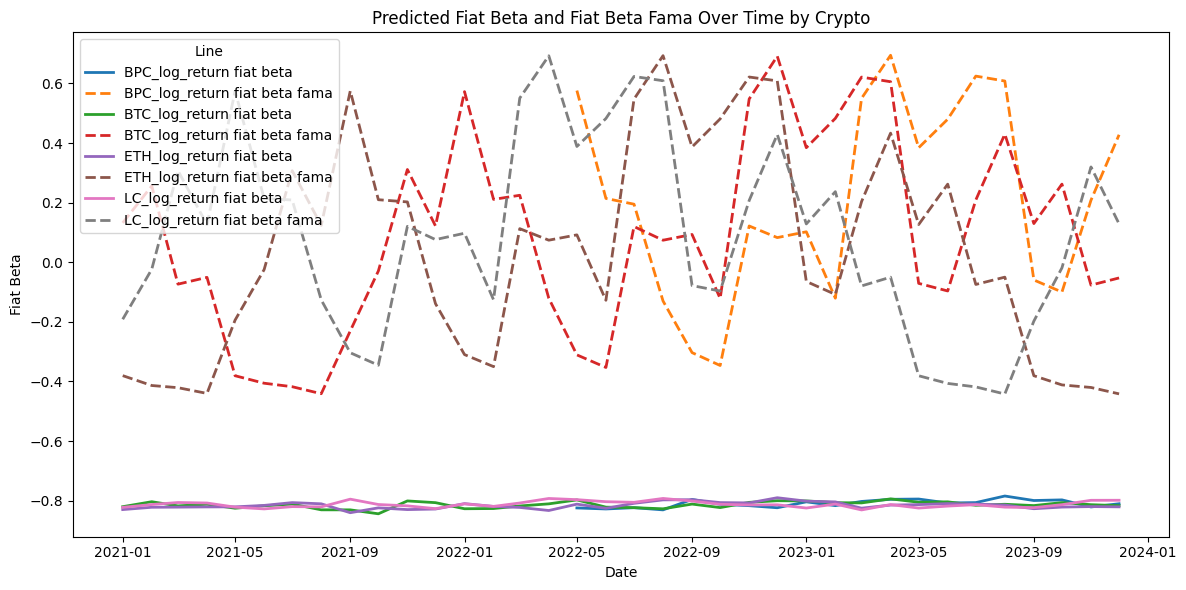

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for crypto in test_df['crypto'].unique():
    df_crypto = test_df[test_df['crypto'] == crypto]
    datetimes = pd.to_datetime(df_crypto['year'].astype(int).astype(str) + '-' + df_crypto['month'].astype(int).astype(str) + '-01')
    plt.plot(datetimes, df_crypto['fiat beta'], label=f"{crypto} fiat beta", linestyle='-', linewidth=2)
    plt.plot(datetimes, df_crypto['fiat beta fama'], label=f"{crypto} fiat beta fama", linestyle='--', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Fiat Beta')
plt.title('Predicted Fiat Beta and Fiat Beta Fama Over Time by Crypto')
plt.legend(title='Line')
plt.tight_layout()
plt.show()


In [ ]:
all_beta_pred = fit_and_predict_beta(market_col='vwretd',fama=True)

In [ ]:
test_df.loc[test_df.index[len(test_df)-len(all_beta_pred):], 'equity beta fama'] = all_beta_pred


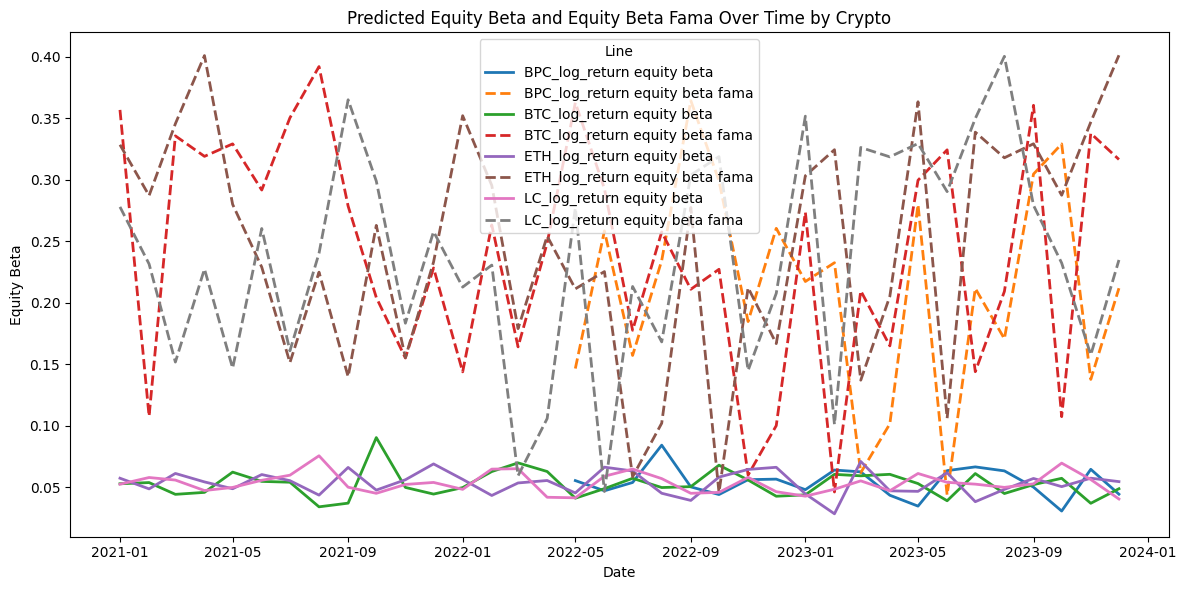

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for crypto in test_df['crypto'].unique():
    df_crypto = test_df[test_df['crypto'] == crypto]
    datetimes = pd.to_datetime(df_crypto['year'].astype(int).astype(str) + '-' + df_crypto['month'].astype(int).astype(str) + '-01')
    plt.plot(datetimes, df_crypto['equity beta'], label=f"{crypto} equity beta", linestyle='-', linewidth=2)
    plt.plot(datetimes, df_crypto['equity beta fama'], label=f"{crypto} equity beta fama", linestyle='--', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Equity Beta')
plt.title('Predicted Equity Beta and Equity Beta Fama Over Time by Crypto')
plt.legend(title='Line')
plt.tight_layout()
plt.show()


In [75]:
# Print descriptive statistics for all beta columns

# Find all columns containing 'beta'
beta_cols = [col for col in test_df.columns if 'beta' in col]

# Compute descriptive statistics for the beta columns
beta_stats = test_df[beta_cols].describe().T

# Print the descriptive statistics
print(beta_stats)



                  count      mean       std       min       25%       50%  \
energy beta       128.0 -0.158010  0.012013 -0.201873 -0.165523 -0.158207   
fiat beta         128.0 -0.813575  0.011236 -0.843976 -0.821755 -0.813358   
equity beta       128.0  0.053330  0.009974  0.028304  0.046490  0.053558   
energy beta fama  128.0 -0.149449  0.074696 -0.280568 -0.202113 -0.158492   
fiat beta fama    128.0  0.093764  0.332177 -0.442066 -0.126010  0.107429   
equity beta fama  128.0  0.235990  0.090646  0.043550  0.164746  0.233790   

                       75%       max  
energy beta      -0.149669 -0.129188  
fiat beta        -0.806311 -0.784324  
equity beta       0.059842  0.090313  
energy beta fama -0.100868  0.004869  
fiat beta fama    0.335909  0.694481  
equity beta fama  0.307702  0.401404  


### Effect of Adding Fama-French Factors on Betas

- **Energy beta:** Became slightly less negative (−0.158 → −0.149) and far more variable (std ↑ from 0.01 → 0.07), indicating Fama factors absorbed some common energy-related risk.  
- **Fiat beta:** Flipped from strongly negative (−0.81) to mildly positive (+0.09) with high dispersion, suggesting its earlier signal overlapped heavily with market factors.  
- **Equity beta:** Increased substantially (0.05 → 0.24) and became more volatile, revealing a stronger underlying link to equities once systematic effects were controlled.  
- **Overall:** Adding Fama-French factors increased dispersion and clarified distinct sources of risk across assets.


In [81]:
test_df.columns

Index(['year', 'month', 'FIAT_log_return', 'GOLD_log_return', 'VDE_log_return',
       'vwretd', 'Mkt-RF', 'SMB', 'HML', 'RF', 'crypto', 'crypto_log_return',
       'ret_mean_w', 'ret_std_w', 'ret_zscore_w', 'FIAT_log_return_mean_w',
       'FIAT_log_return_std_w', 'FIAT_log_return_zscore_w',
       'GOLD_log_return_mean_w', 'GOLD_log_return_std_w',
       'GOLD_log_return_zscore_w', 'VDE_log_return_mean_w',
       'VDE_log_return_std_w', 'VDE_log_return_zscore_w', 'vwretd_mean_w',
       'vwretd_std_w', 'vwretd_zscore_w', 'corr_market_w', 'energy beta',
       'fiat beta', 'equity beta', 'energy beta fama', 'fiat beta fama',
       'equity beta fama', 'energy_beta_quartile', 'fiat_beta_quartile',
       'equity_beta_quartile'],
      dtype='object')

In [83]:

# Print mean beta and mean realized excess return by quartile, as tables per asset class

import pandas as pd

# Beta columns and their respective benchmarks
asset_classes = {
    'energy':  ('energy beta', 'VDE_log_return'),
    'fiat':    ('fiat beta',   'FIAT_log_return'),
    'equity':  ('equity beta', 'vwretd'),
}

quartile_results = {}

for asset_label, (beta_col, benchmark_col) in asset_classes.items():
    print(f"\n### Asset class: {asset_label.capitalize()}\n")
    # For each crypto, take its most recent row to determine current beta for quartile assignment
    last_rows = test_df.sort_values(['year', 'month']).groupby('crypto').tail(1)
    cryptos_sorted = last_rows.sort_values(beta_col)['crypto'].values
    # Assign quartiles (1 per crypto, assumed 4 cryptos)
    quartiles = {i+1: [cryptos_sorted[i]] for i in range(len(cryptos_sorted))}
    
    table_rows = []
    results = []
    for q in range(1, 5):
        members = quartiles[q]
        member_name = members[0]
        member_rows = test_df[test_df['crypto'] == member_name]
        mean_beta = member_rows[beta_col].mean()
        if benchmark_col in member_rows.columns:
            mean_ret = (member_rows['crypto_log_return'] - member_rows[benchmark_col]).mean()
        else:
            mean_ret = member_rows['crypto_log_return'].mean()
        table_rows.append([
            f"Q{q}", member_name, f"{mean_beta:.3f}", f"{mean_ret:.4f}"
        ])
        results.append(dict(quartile=q, member=member_name, avg_beta=mean_beta, mean_excess_ret=mean_ret))
    # Q4-Q1 diff:
    if len(results) >= 4:
        diff_beta = results[3]['avg_beta'] - results[0]['avg_beta']
        diff_ret = results[3]['mean_excess_ret'] - results[0]['mean_excess_ret']
        table_rows.append([
            "Q4 - Q1", f"{results[3]['member']} - {results[0]['member']}", f"{diff_beta:.3f}", f"{diff_ret:.4f}"
        ])

    # Print as a nice table
    print(pd.DataFrame(
        table_rows, 
        columns=["Quartile", "Crypto", "Mean Beta", "Mean Excess Return"]
    ).to_string(index=False))
    quartile_results[asset_label] = results




### Asset class: Energy

Quartile                         Crypto Mean Beta Mean Excess Return
      Q1                  LC_log_return    -0.158            -0.0400
      Q2                 ETH_log_return    -0.158             0.0063
      Q3                 BPC_log_return    -0.157            -0.0328
      Q4                 BTC_log_return    -0.158            -0.0146
 Q4 - Q1 BTC_log_return - LC_log_return    -0.000             0.0254

### Asset class: Fiat

Quartile                         Crypto Mean Beta Mean Excess Return
      Q1                 ETH_log_return    -0.816             0.0295
      Q2                 BTC_log_return    -0.814             0.0087
      Q3                 BPC_log_return    -0.810            -0.0095
      Q4                  LC_log_return    -0.813            -0.0167
 Q4 - Q1 LC_log_return - ETH_log_return     0.004            -0.0462

### Asset class: Equity

Quartile                         Crypto Mean Beta Mean Excess Return
      Q1                  L